# ViT-B/16 — autoLRP attribution

Vision Transformer with 14×14 = 196 patches + CLS, from torchvision (ImageNet weights). autoLRP rewrites the fused multi-head attention during the forward so the softmax, the two products and the projections are ordinary nodes. Gamma on every linear node, attention weights treated as constants (the `CPLRP` fragment).

In [1]:
import sys
sys.path.insert(0, '..')          # examples/showcase: _common
sys.path.insert(0, '../../..')    # repo root: autoLRP (or `pip install -e .`)
import torch
from torchvision.models import vit_b_16, ViT_B_16_Weights

import autolrp
from autolrp import LRPConfig, BASE, CPLRP
from _common import load_showcase_images, show_vision_attribution, show_vision_comparison, imagenet_classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1).eval().to(device)
images = load_showcase_images(device=device)
print(f'Loaded {len(images)} showcase images')

Loaded 6 showcase images


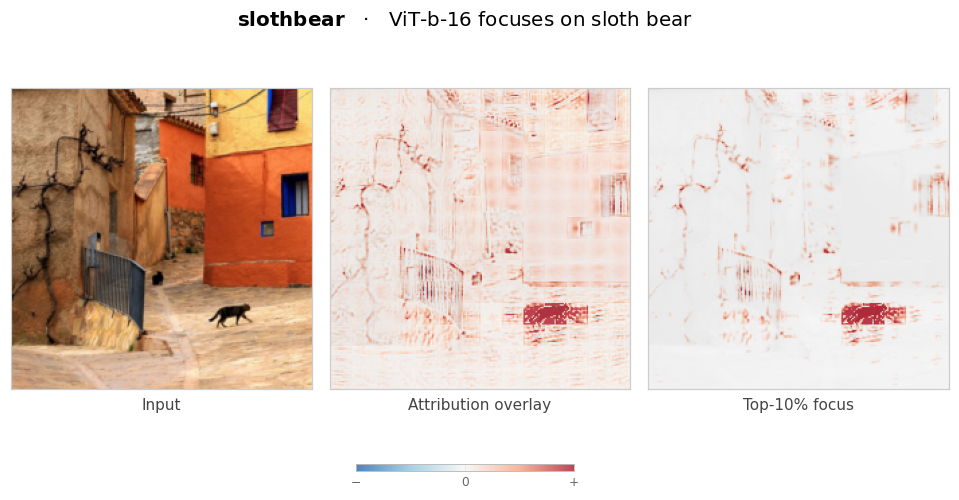

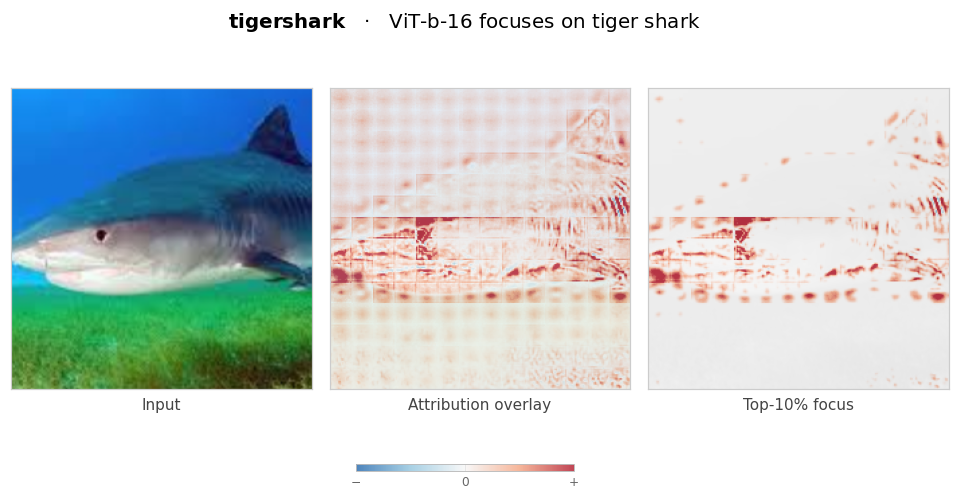

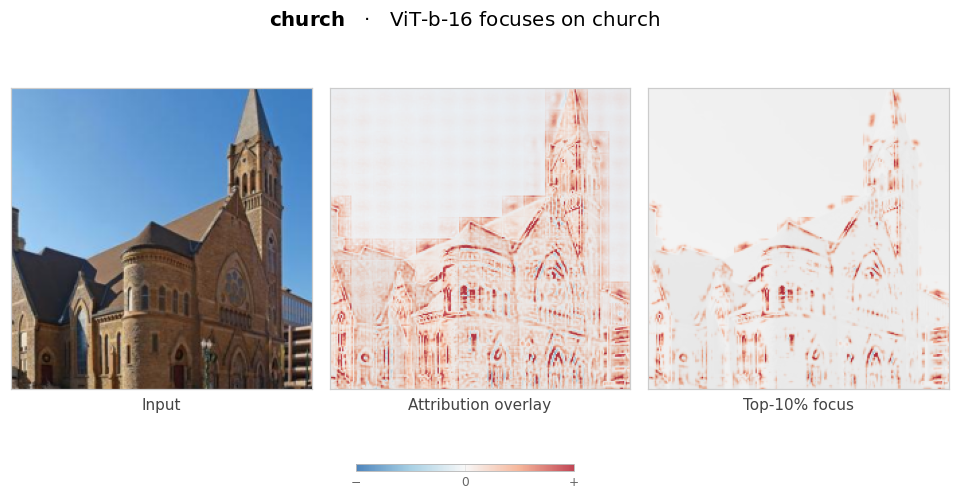

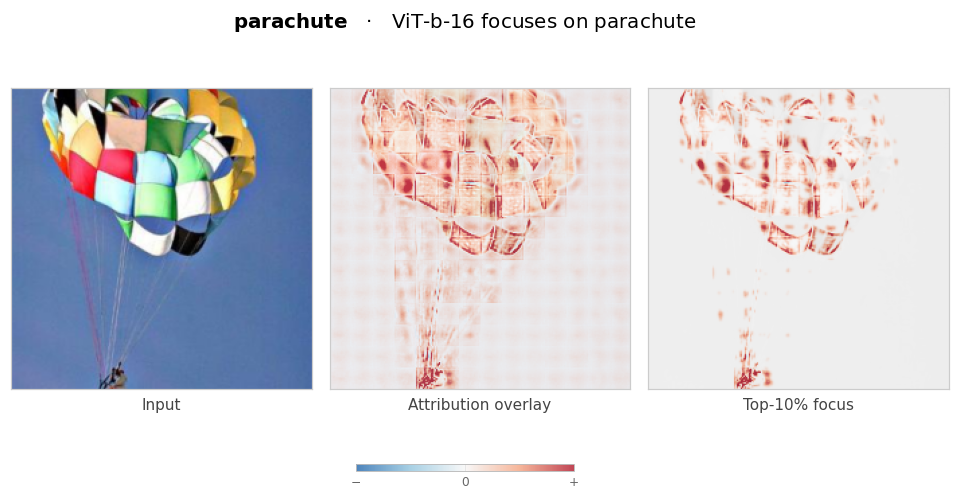

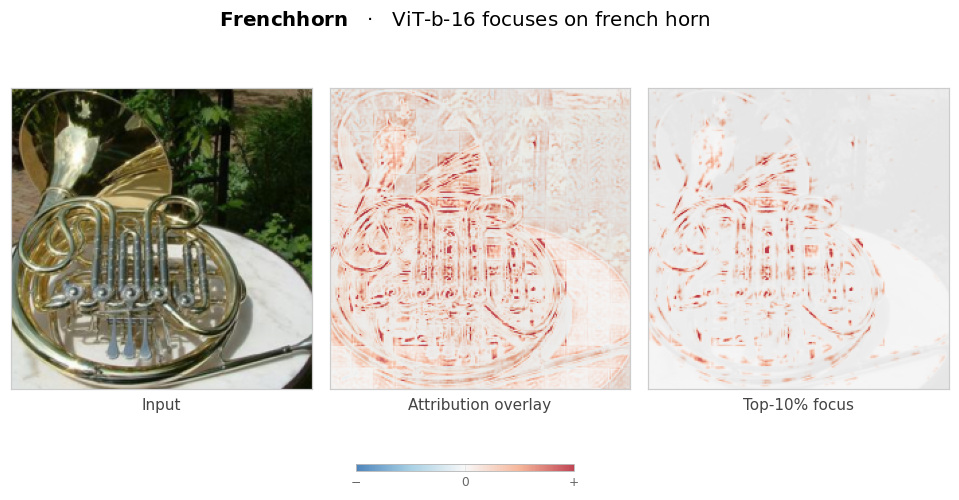

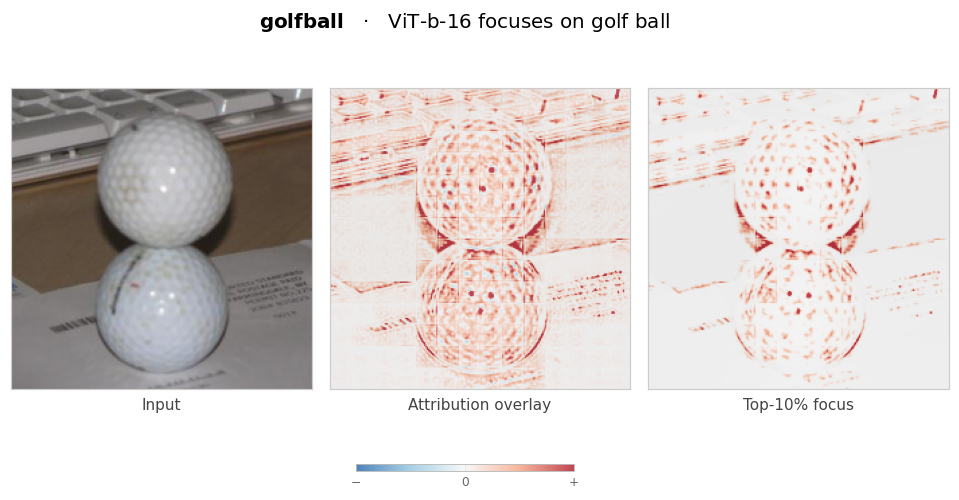

In [3]:
for img, label in images:
    with torch.no_grad():
        pred = model(img).argmax(-1).item()
    pred_name = imagenet_classes()[pred]
    x = autolrp.tensor(img.clone())
    gamma = ('gamma', {'gamma': 0.25})
    model(x)[0, pred].lrp(config=LRPConfig(
        rule={**BASE, 'AddmmBackward': gamma, 'MmBackward': gamma, 'ConvolutionBackward': gamma, **CPLRP},
    ))
    show_vision_attribution(
        img,
        x.relevance,
        pred_label=pred_name,
        rule_name=f'ViT-b-16 focuses on {pred_name.lower()}'
    )